In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = fetch_california_housing(as_frame=True)

X = data.data
y = data.target

df = X.copy()
df["Target"] = y

print("Dataset Shape:", df.shape)

display(df.head(10))

Dataset Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [3]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nStatistical Summary:")
display(df.describe().T)

DATASET INFORMATION

Shape:
(20640, 9)

Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Target']

Data Types:


,Data Type
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
Target,float64



Missing Values:


,Missing Values
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Target,0



Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
Target,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


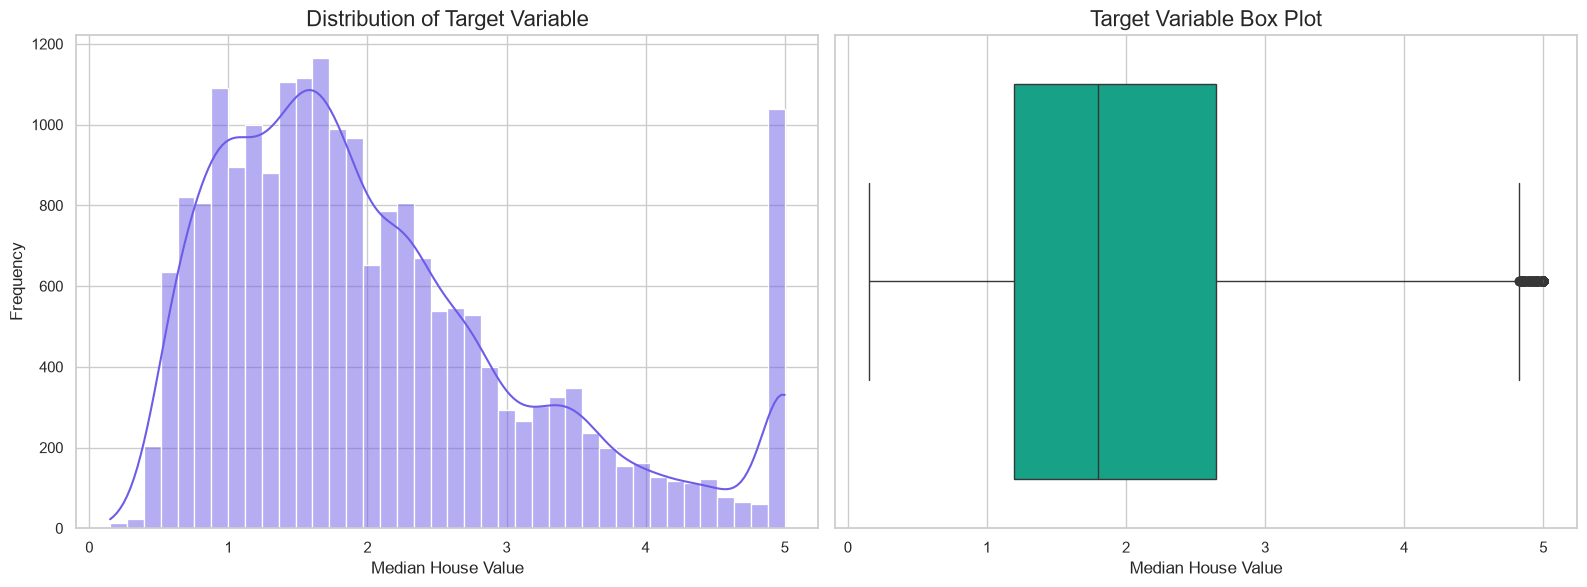

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    y,
    bins=40,
    kde=True,
    color="#6C5CE7",
    ax=axes[0]
)

axes[0].set_title("Distribution of Target Variable")
axes[0].set_xlabel("Median House Value")
axes[0].set_ylabel("Frequency")

sns.boxplot(
    x=y,
    color="#00B894",
    ax=axes[1]
)

axes[1].set_title("Target Variable Box Plot")
axes[1].set_xlabel("Median House Value")

plt.tight_layout()
plt.show()

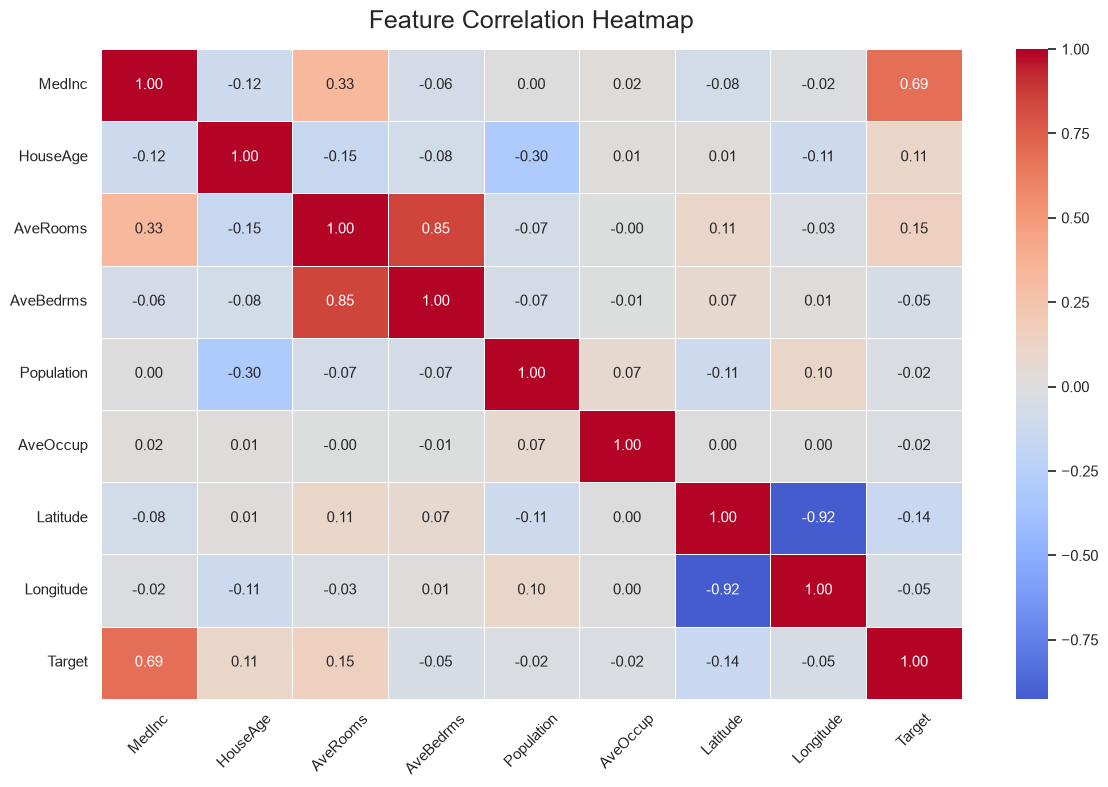

In [5]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    center=0
)

plt.title("Feature Correlation Heatmap", fontsize=18, pad=15)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

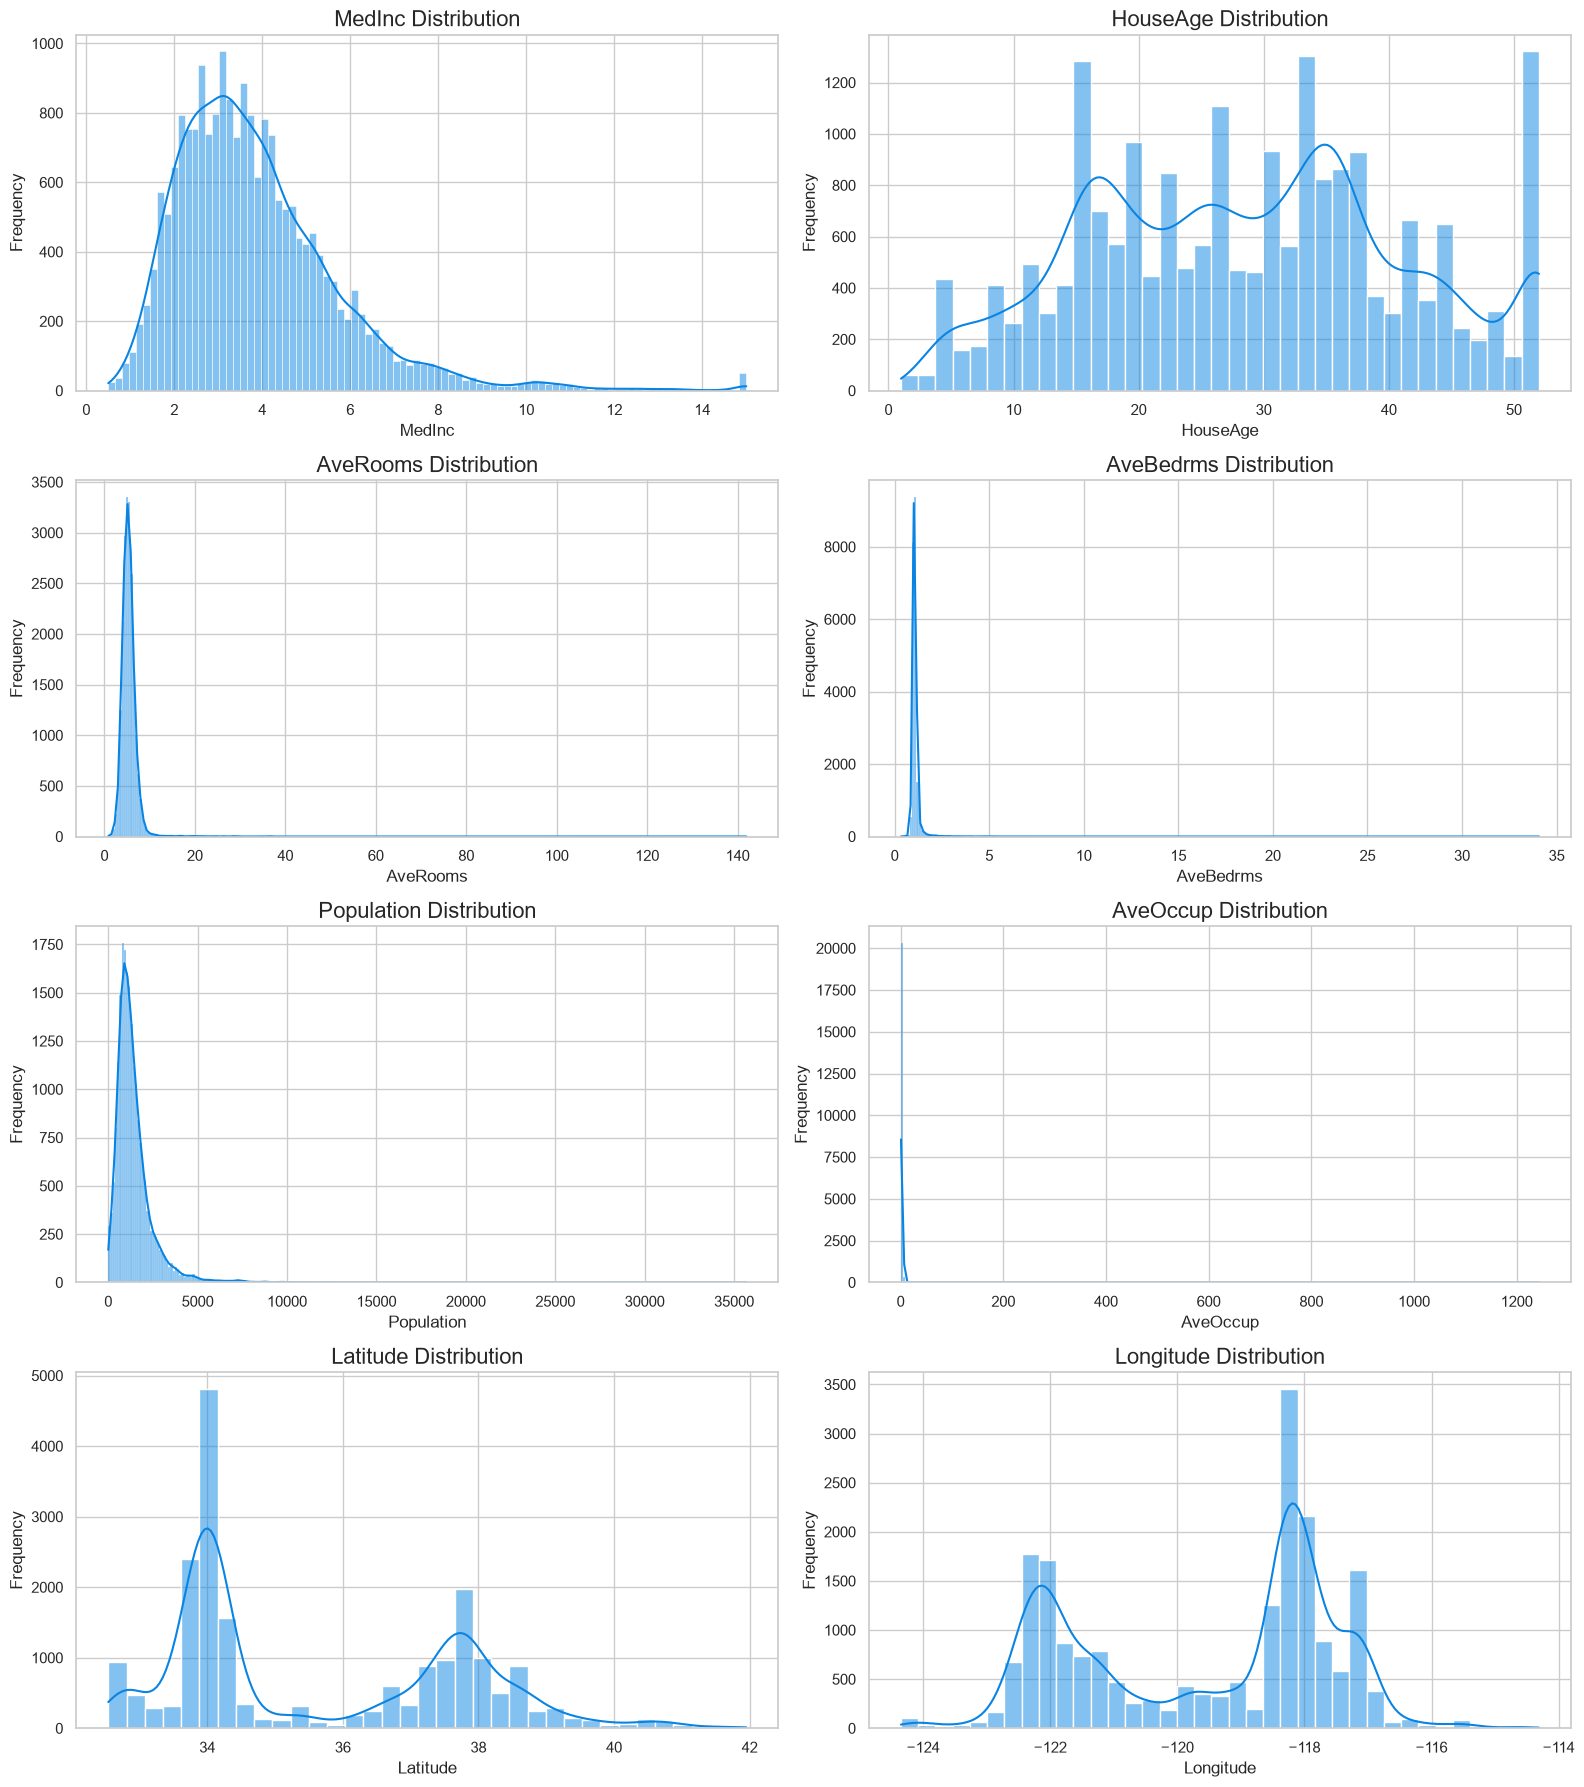

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))

for ax, column in zip(axes.flatten(), X.columns):
    sns.histplot(
        X[column],
        kde=True,
        color="#0984E3",
        ax=ax
    )
    ax.set_title(f"{column} Distribution")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

print("\nTraining Target Mean:", round(y_train.mean(), 4))
print("Testing Target Mean :", round(y_test.mean(), 4))

Training Data Shape: (16512, 8)
Testing Data Shape : (4128, 8)

Training Target Mean: 2.0719
Testing Target Mean : 2.055


In [8]:
model = CatBoostRegressor(
    iterations=700,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=False,
    l2_leaf_reg=3,
    random_strength=1,
    bagging_temperature=1
)

print(model)

CatBoostRegressor(bagging_temperature=1, depth=6, eval_metric='RMSE', iterations=700, l2_leaf_reg=3, learning_rate=0.05, loss_function='RMSE', random_seed=42, random_strength=1, verbose=False)


In [9]:
model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True,
    early_stopping_rounds=50,
    verbose=100
)

print("\nModel training completed!")
print("Best Iteration:", model.get_best_iteration())

0:	learn: 1.1244518	test: 1.1141317	best: 1.1141317 (0)	total: 136ms	remaining: 1m 35s
100:	learn: 0.5369823	test: 0.5577451	best: 0.5577451 (100)	total: 429ms	remaining: 2.54s
200:	learn: 0.4900335	test: 0.5181736	best: 0.5181736 (200)	total: 712ms	remaining: 1.77s
300:	learn: 0.4556483	test: 0.4928652	best: 0.4928652 (300)	total: 1.01s	remaining: 1.34s
400:	learn: 0.4337255	test: 0.4799680	best: 0.4799680 (400)	total: 1.27s	remaining: 951ms
500:	learn: 0.4161438	test: 0.4714293	best: 0.4714293 (500)	total: 1.54s	remaining: 612ms
600:	learn: 0.4028231	test: 0.4657025	best: 0.4657025 (600)	total: 1.79s	remaining: 295ms
699:	learn: 0.3909171	test: 0.4610561	best: 0.4610561 (699)	total: 2.05s	remaining: 0us

bestTest = 0.4610560922
bestIteration = 699


Model training completed!
Best Iteration: 699


In [10]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("First 10 Predictions:")
display(
    pd.DataFrame({
        "Actual": y_test.iloc[:10].values,
        "Predicted": y_test_pred[:10]
    })
)

First 10 Predictions:


,Actual,Predicted
0,0.47700,0.522899
1,0.45800,0.961967
2,5.00001,4.943478
3,2.18600,2.415156
4,2.78000,2.433608
5,1.58700,1.597646
6,1.98200,2.344380
7,1.57500,1.615857
8,3.40000,2.792078
9,4.46600,4.760764


In [11]:
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Training": [
        train_mae,
        train_mse,
        train_rmse,
        train_r2
    ],
    "Testing": [
        test_mae,
        test_mse,
        test_rmse,
        test_r2
    ]
})

display(metrics)

print(f"Training R² : {train_r2:.4f}")
print(f"Testing R²  : {test_r2:.4f}")
print(f"Testing RMSE: {test_rmse:.4f}")

,Metric,Training,Testing
0,MAE,0.270225,0.306325
1,MSE,0.152816,0.212573
2,RMSE,0.390917,0.461056
3,R²,0.885683,0.837781


Training R² : 0.8857
Testing R²  : 0.8378
Testing RMSE: 0.4611


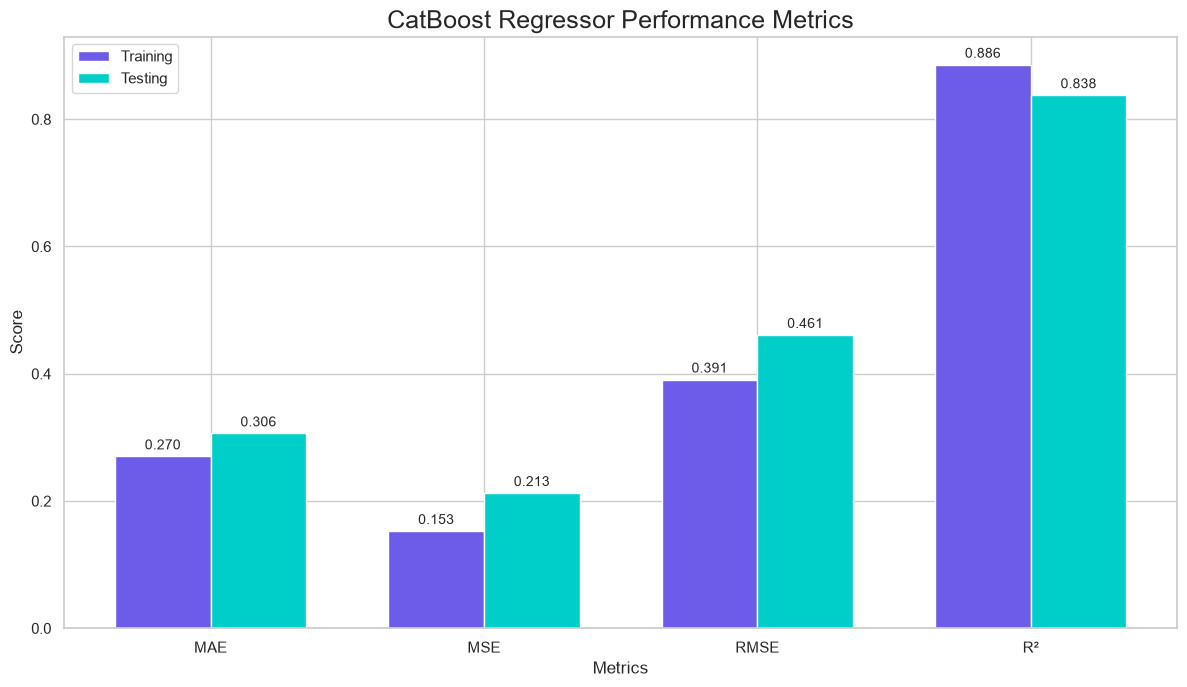

In [12]:
metric_names = ["MAE", "MSE", "RMSE", "R²"]
train_values = [train_mae, train_mse, train_rmse, train_r2]
test_values = [test_mae, test_mse, test_rmse, test_r2]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(
    x - width / 2,
    train_values,
    width,
    label="Training",
    color="#6C5CE7"
)

bars2 = ax.bar(
    x + width / 2,
    test_values,
    width,
    label="Testing",
    color="#00CEC9"
)

ax.set_title("CatBoost Regressor Performance Metrics", fontsize=18)
ax.set_xlabel("Metrics")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            fontsize=10
        )

plt.tight_layout()
plt.show()

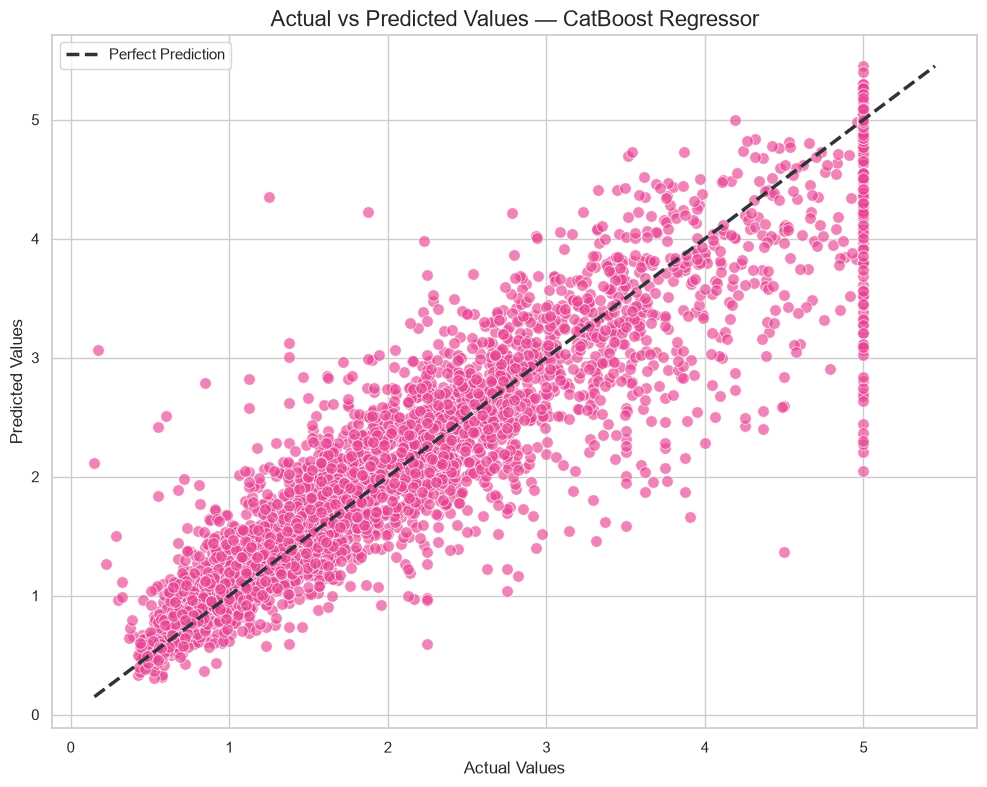

In [13]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=y_test,
    y=y_test_pred,
    color="#E84393",
    alpha=0.65,
    s=70,
    edgecolor="white"
)

min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="#2D3436",
    linestyle="--",
    linewidth=2.5,
    label="Perfect Prediction"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values — CatBoost Regressor")
plt.legend()
plt.tight_layout()
plt.show()

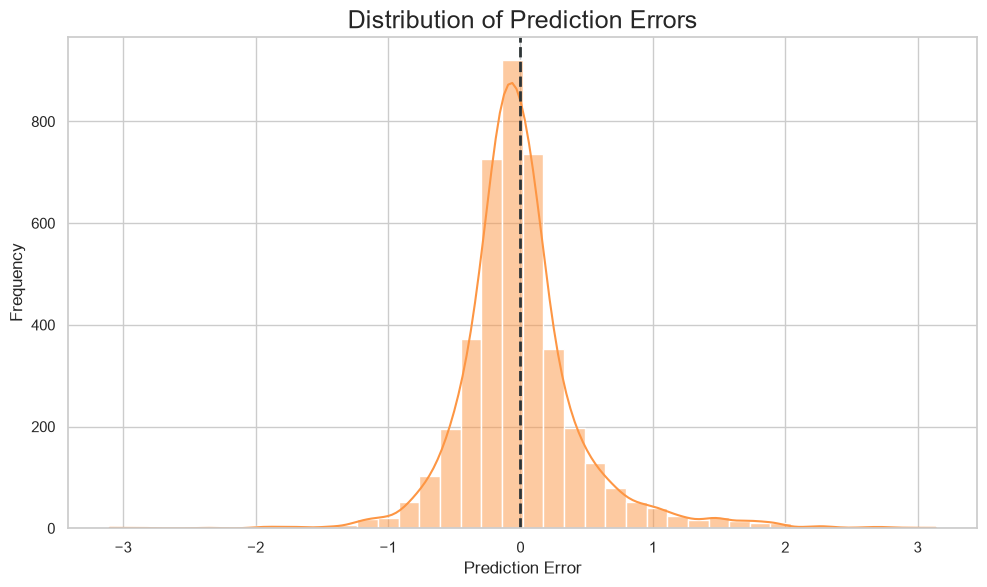

In [14]:
prediction_errors = y_test - y_test_pred

plt.figure(figsize=(10, 6))

sns.histplot(
    prediction_errors,
    bins=40,
    kde=True,
    color="#FD9644"
)

plt.axvline(
    0,
    color="#2D3436",
    linestyle="--",
    linewidth=2
)

plt.title("Distribution of Prediction Errors", fontsize=18)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

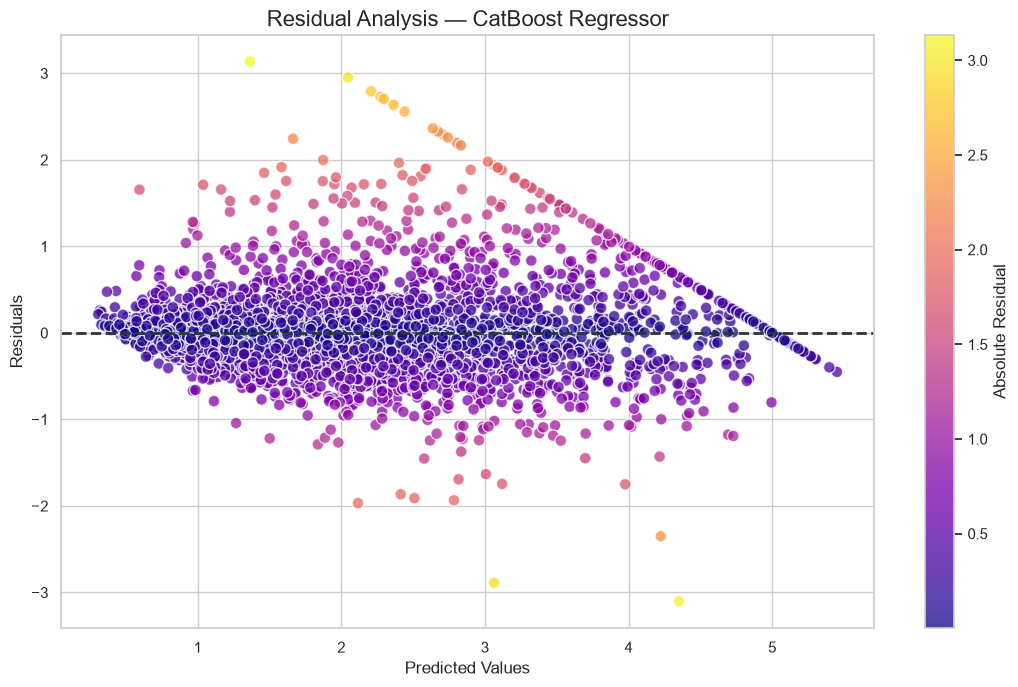

In [15]:
residuals = y_test - y_test_pred

plt.figure(figsize=(11, 7))

scatter = plt.scatter(
    y_test_pred,
    residuals,
    c=np.abs(residuals),
    cmap="plasma",
    alpha=0.75,
    s=70,
    edgecolors="white"
)

plt.axhline(
    0,
    color="#2D3436",
    linestyle="--",
    linewidth=2
)

plt.colorbar(scatter, label="Absolute Residual")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Analysis — CatBoost Regressor")

plt.tight_layout()
plt.show()

In [16]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
0,MedInc,33.701447
6,Latitude,21.429468
7,Longitude,18.825848
5,AveOccup,14.663745
1,HouseAge,5.192413
2,AveRooms,3.190158
3,AveBedrms,1.539593
4,Population,1.457328


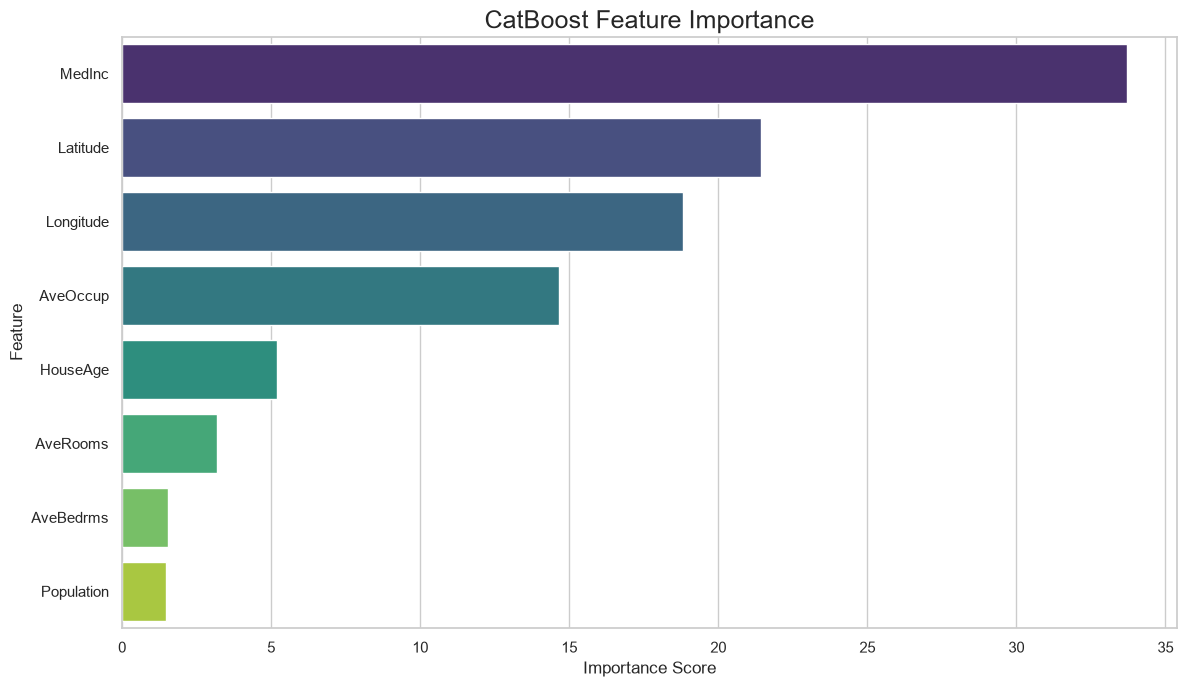

In [17]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("CatBoost Feature Importance", fontsize=18)
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

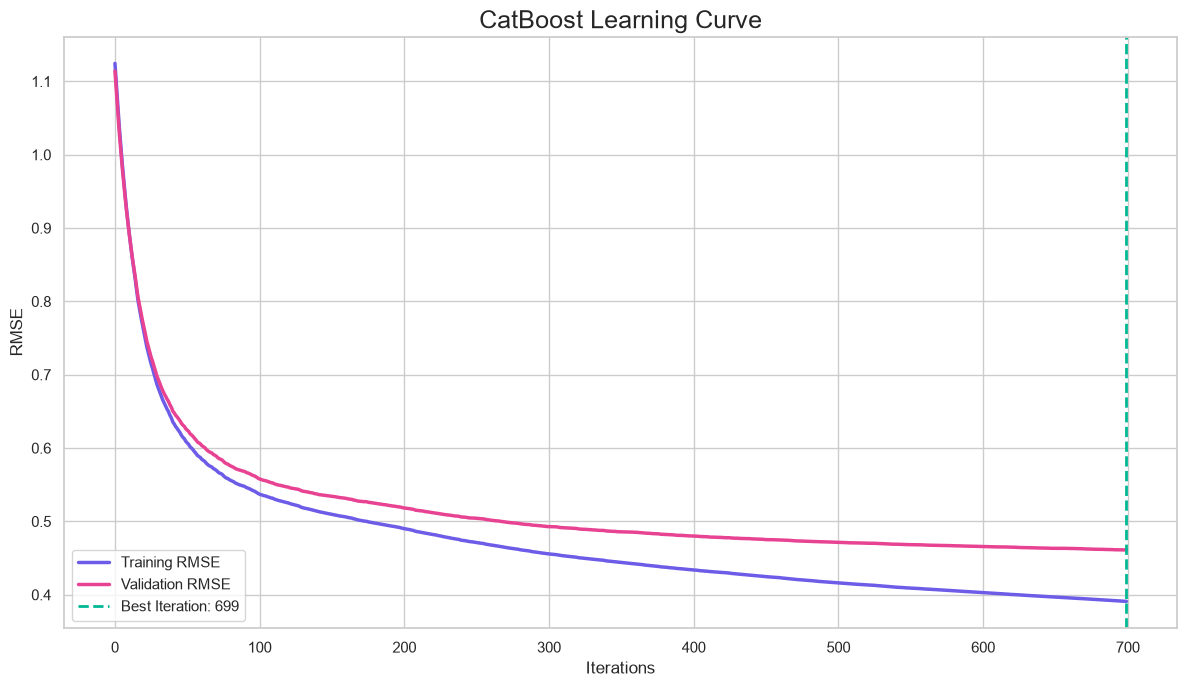

In [18]:
evals_result = model.get_evals_result()

train_rmse_history = evals_result["learn"]["RMSE"]
validation_rmse_history = evals_result["validation"]["RMSE"]

plt.figure(figsize=(12, 7))

plt.plot(
    train_rmse_history,
    label="Training RMSE",
    color="#6C5CE7",
    linewidth=2.5
)

plt.plot(
    validation_rmse_history,
    label="Validation RMSE",
    color="#E84393",
    linewidth=2.5
)

best_iteration = model.get_best_iteration()

plt.axvline(
    best_iteration,
    color="#00B894",
    linestyle="--",
    linewidth=2,
    label=f"Best Iteration: {best_iteration}"
)

plt.title("CatBoost Learning Curve", fontsize=18)
plt.xlabel("Iterations")
plt.ylabel("RMSE")
plt.legend()

plt.tight_layout()
plt.show()

,Iterations,RMSE
0,50,0.626084
1,100,0.558674
2,200,0.518499
3,300,0.492914
4,400,0.480130
5,500,0.471527
6,700,0.461056
7,900,0.454323


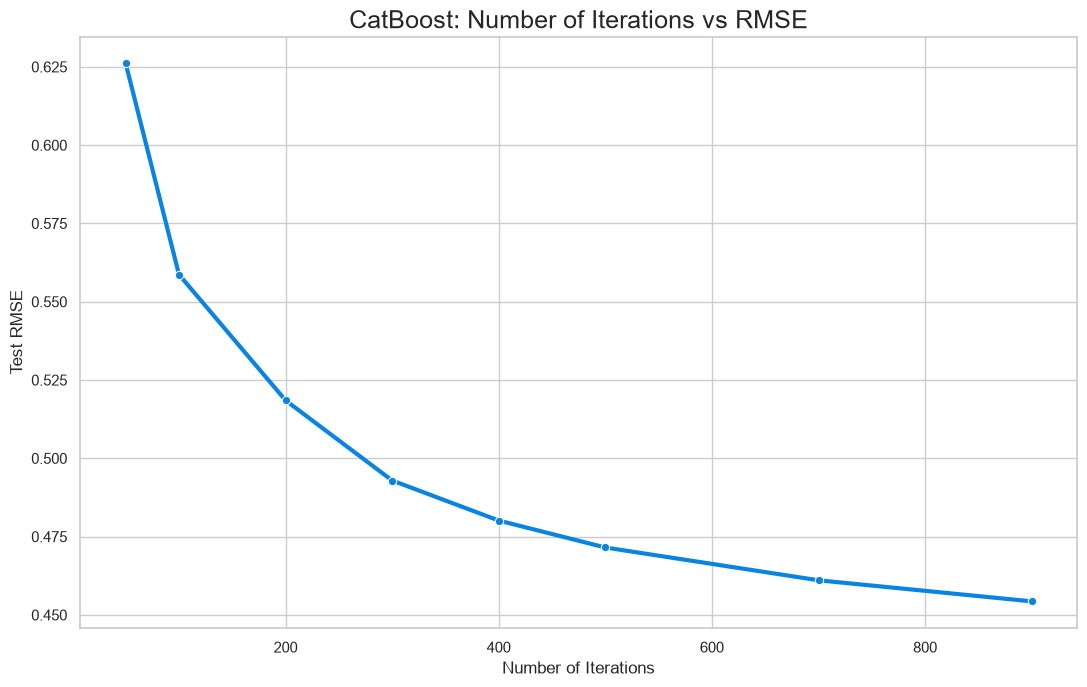

In [19]:
iterations = [50, 100, 200, 300, 400, 500, 700, 900]

rmse_scores = []

for n in iterations:
    temp_model = CatBoostRegressor(
        iterations=n,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )

    temp_model.fit(X_train, y_train)

    temp_prediction = temp_model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(y_test, temp_prediction)
    )

    rmse_scores.append(rmse)

iteration_results = pd.DataFrame({
    "Iterations": iterations,
    "RMSE": rmse_scores
})

display(iteration_results)

plt.figure(figsize=(11, 7))

sns.lineplot(
    data=iteration_results,
    x="Iterations",
    y="RMSE",
    marker="o",
    linewidth=3,
    color="#0984E3"
)

plt.title("CatBoost: Number of Iterations vs RMSE", fontsize=18)
plt.xlabel("Number of Iterations")
plt.ylabel("Test RMSE")

plt.tight_layout()
plt.show()

,Learning Rate,RMSE
0,0.01,0.559787
1,0.03,0.491624
2,0.05,0.471527
3,0.10,0.453483
4,0.15,0.444504
5,0.20,0.444877


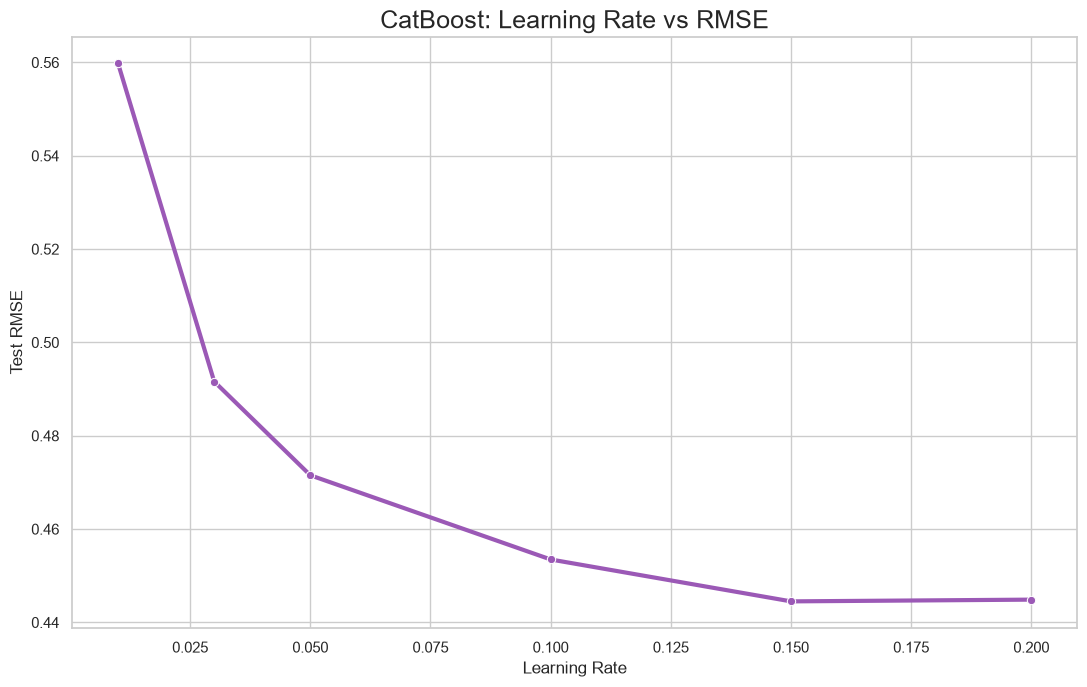

In [20]:
learning_rates = [0.01, 0.03, 0.05, 0.10, 0.15, 0.20]

learning_rate_scores = []

for lr in learning_rates:
    temp_model = CatBoostRegressor(
        iterations=500,
        learning_rate=lr,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )

    temp_model.fit(X_train, y_train)

    temp_prediction = temp_model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(y_test, temp_prediction)
    )

    learning_rate_scores.append(rmse)

learning_rate_results = pd.DataFrame({
    "Learning Rate": learning_rates,
    "RMSE": learning_rate_scores
})

display(learning_rate_results)

plt.figure(figsize=(11, 7))

sns.lineplot(
    data=learning_rate_results,
    x="Learning Rate",
    y="RMSE",
    marker="o",
    linewidth=3,
    color="#9B59B6"
)

plt.title("CatBoost: Learning Rate vs RMSE", fontsize=18)
plt.xlabel("Learning Rate")
plt.ylabel("Test RMSE")

plt.tight_layout()
plt.show()

,Depth,RMSE
0,3,0.513946
1,4,0.495143
2,5,0.482314
3,6,0.471527
4,7,0.464545
5,8,0.456280
6,10,0.452957


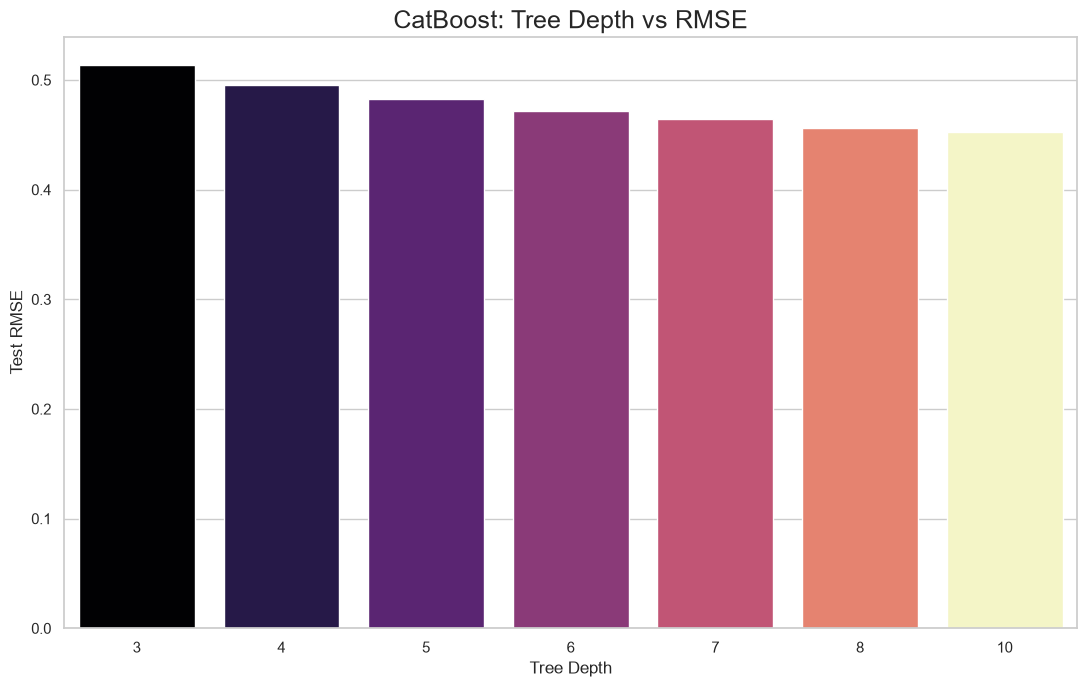

In [21]:
depth_values = [3, 4, 5, 6, 7, 8, 10]

depth_scores = []

for depth in depth_values:
    temp_model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=depth,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )

    temp_model.fit(X_train, y_train)

    temp_prediction = temp_model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(y_test, temp_prediction)
    )

    depth_scores.append(rmse)

depth_results = pd.DataFrame({
    "Depth": depth_values,
    "RMSE": depth_scores
})

display(depth_results)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=depth_results,
    x="Depth",
    y="RMSE",
    hue="Depth",
    palette="magma",
    legend=False
)

plt.title("CatBoost: Tree Depth vs RMSE", fontsize=18)
plt.xlabel("Tree Depth")
plt.ylabel("Test RMSE")

plt.tight_layout()
plt.show()

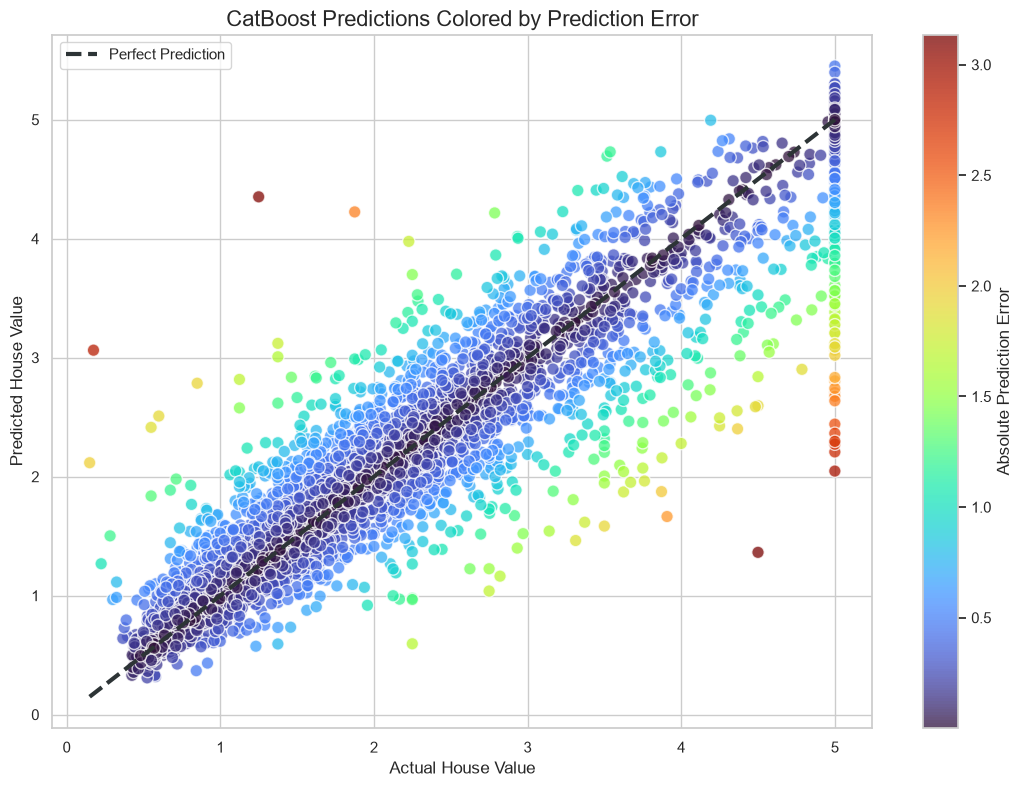

In [22]:
absolute_error = np.abs(y_test - y_test_pred)

plt.figure(figsize=(11, 8))

scatter = plt.scatter(
    y_test,
    y_test_pred,
    c=absolute_error,
    cmap="turbo",
    s=80,
    alpha=0.75,
    edgecolors="white"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    linewidth=3,
    color="#2D3436",
    label="Perfect Prediction"
)

plt.colorbar(
    scatter,
    label="Absolute Prediction Error"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("CatBoost Predictions Colored by Prediction Error")
plt.legend()

plt.tight_layout()
plt.show()

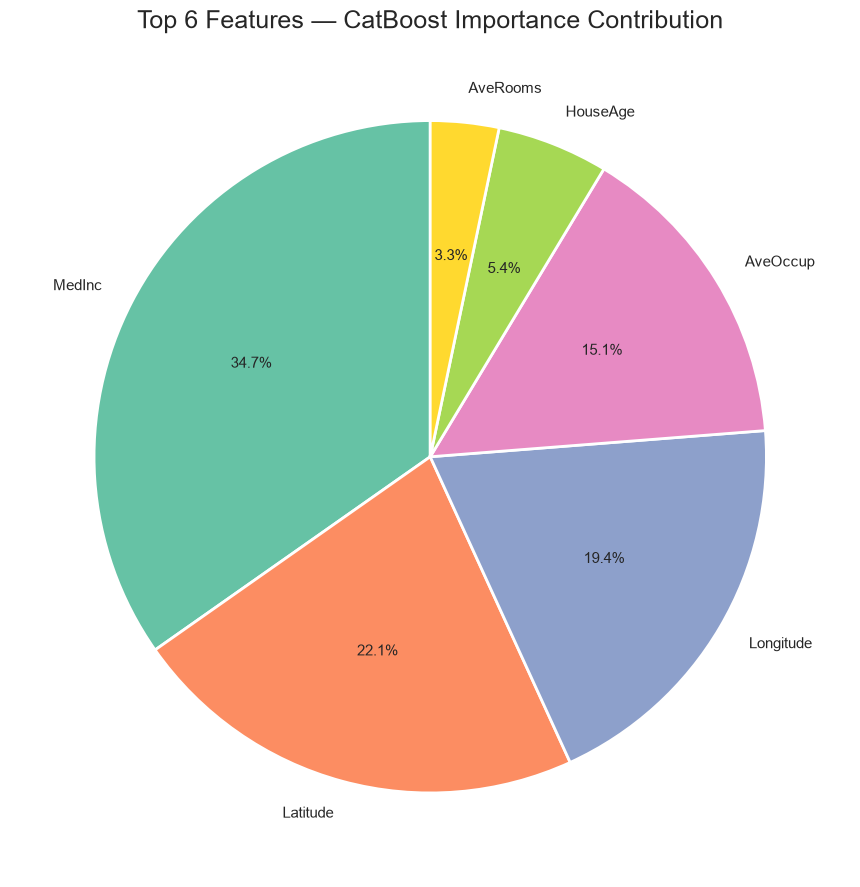

In [23]:
top_features = feature_importance.head(6)

plt.figure(figsize=(9, 9))

plt.pie(
    top_features["Importance"],
    labels=top_features["Feature"],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", len(top_features)),
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

plt.title(
    "Top 6 Features — CatBoost Importance Contribution",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [24]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred,
    "Error": y_test.values - y_test_pred,
    "Absolute Error": np.abs(y_test.values - y_test_pred),
    "Percentage Error": (
        np.abs((y_test.values - y_test_pred) / y_test.values) * 100
    )
})

comparison = comparison.sort_values(
    by="Absolute Error",
    ascending=False
)

display(comparison.head(20))

,Actual,Predicted,Error,Absolute Error,Percentage Error
3710,4.50000,1.363559,3.136441,3.136441,69.698688
285,1.25000,4.351846,-3.101846,3.101846,248.147682
1649,5.00001,2.046560,2.953450,2.953450,59.068876
2927,0.17500,3.062578,-2.887578,2.887578,1650.044853
872,5.00001,2.207625,2.792385,2.792385,55.847580
2250,5.00001,2.272833,2.727177,2.727177,54.543426
3693,5.00001,2.296269,2.703741,2.703741,54.074709
1865,5.00001,2.364145,2.635865,2.635865,52.717191
1140,5.00001,2.441110,2.558900,2.558900,51.177903
3755,5.00001,2.637106,2.362904,2.362904,47.257978


In [25]:
best_predictions = comparison.sort_values(
    by="Absolute Error"
).head(10)

worst_predictions = comparison.sort_values(
    by="Absolute Error",
    ascending=False
).head(10)

print("BEST PREDICTIONS")
display(best_predictions)

print("\nWORST PREDICTIONS")
display(worst_predictions)

BEST PREDICTIONS


,Actual,Predicted,Error,Absolute Error,Percentage Error
192,1.53000,1.530034,-0.000034,0.000034,0.002192
2263,1.71300,1.713173,-0.000173,0.000173,0.010113
693,1.12700,1.127197,-0.000197,0.000197,0.017495
2895,2.79500,2.795241,-0.000241,0.000241,0.008623
1151,0.97300,0.972614,0.000386,0.000386,0.039665
4125,5.00001,5.000552,-0.000542,0.000542,0.010838
2981,1.75000,1.749349,0.000651,0.000651,0.037178
1673,0.90100,0.901654,-0.000654,0.000654,0.072546
1231,1.30300,1.302200,0.000800,0.000800,0.061364
682,1.60600,1.605102,0.000898,0.000898,0.055893



WORST PREDICTIONS


,Actual,Predicted,Error,Absolute Error,Percentage Error
3710,4.50000,1.363559,3.136441,3.136441,69.698688
285,1.25000,4.351846,-3.101846,3.101846,248.147682
1649,5.00001,2.046560,2.953450,2.953450,59.068876
2927,0.17500,3.062578,-2.887578,2.887578,1650.044853
872,5.00001,2.207625,2.792385,2.792385,55.847580
2250,5.00001,2.272833,2.727177,2.727177,54.543426
3693,5.00001,2.296269,2.703741,2.703741,54.074709
1865,5.00001,2.364145,2.635865,2.635865,52.717191
1140,5.00001,2.441110,2.558900,2.558900,51.177903
3755,5.00001,2.637106,2.362904,2.362904,47.257978


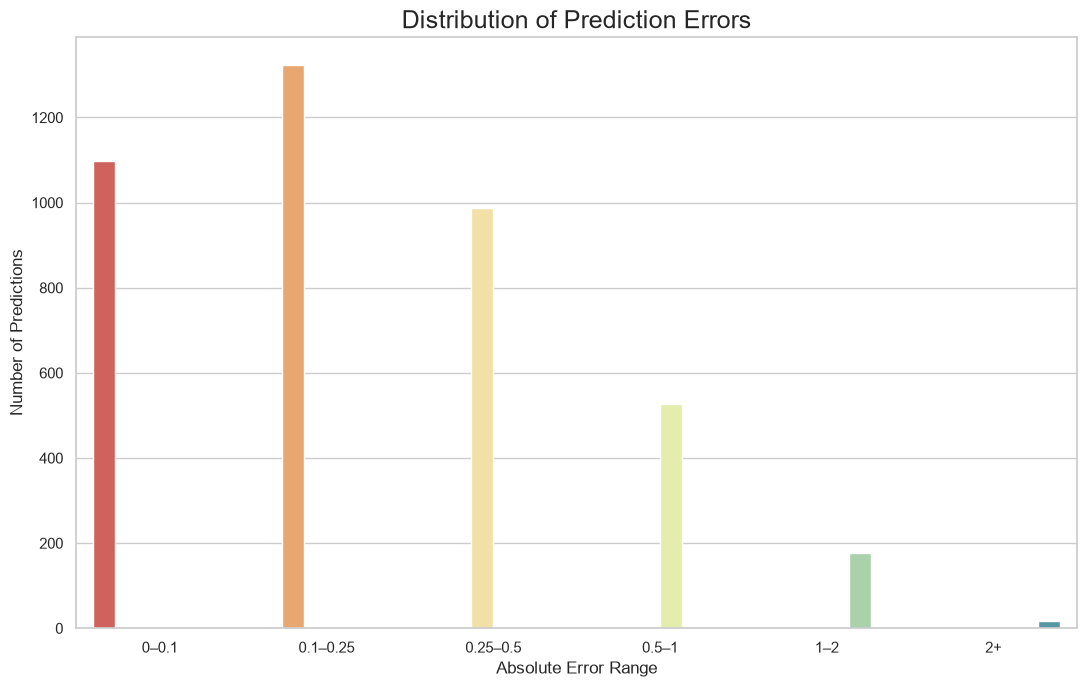

In [26]:
error_ranges = pd.cut(
    comparison["Absolute Error"],
    bins=[0, 0.1, 0.25, 0.5, 1, 2, np.inf],
    labels=[
        "0–0.1",
        "0.1–0.25",
        "0.25–0.5",
        "0.5–1",
        "1–2",
        "2+"
    ]
)

error_distribution = error_ranges.value_counts().sort_index()

plt.figure(figsize=(11, 7))

sns.barplot(
    x=error_distribution.index,
    y=error_distribution.values,
    hue=error_distribution.index,
    palette="Spectral",
    legend=False
)

plt.title("Distribution of Prediction Errors", fontsize=18)
plt.xlabel("Absolute Error Range")
plt.ylabel("Number of Predictions")

plt.tight_layout()
plt.show()

In [27]:
print("=" * 70)
print("CATBOOST REGRESSOR — MODEL SUMMARY")
print("=" * 70)

print(f"Number of Training Samples : {len(X_train):,}")
print(f"Number of Testing Samples  : {len(X_test):,}")
print(f"Number of Features         : {X.shape[1]}")

print("\nModel Parameters")
print("-" * 70)
print(f"Iterations                 : {model.get_param('iterations')}")
print(f"Learning Rate              : {model.get_param('learning_rate')}")
print(f"Depth                      : {model.get_param('depth')}")
print(f"Loss Function              : {model.get_param('loss_function')}")

print("\nPerformance")
print("-" * 70)
print(f"Training MAE               : {train_mae:.4f}")
print(f"Testing MAE                : {test_mae:.4f}")
print(f"Training RMSE              : {train_rmse:.4f}")
print(f"Testing RMSE               : {test_rmse:.4f}")
print(f"Training R²                : {train_r2:.4f}")
print(f"Testing R²                 : {test_r2:.4f}")

print("\nBest Training Iteration")
print("-" * 70)
print(f"Best Iteration             : {model.get_best_iteration()}")

print("=" * 70)

CATBOOST REGRESSOR — MODEL SUMMARY
Number of Training Samples : 16,512
Number of Testing Samples  : 4,128
Number of Features         : 8

Model Parameters
----------------------------------------------------------------------
Iterations                 : 700
Learning Rate              : 0.05
Depth                      : 6
Loss Function              : RMSE

Performance
----------------------------------------------------------------------
Training MAE               : 0.2702
Testing MAE                : 0.3063
Training RMSE              : 0.3909
Testing RMSE               : 0.4611
Training R²                : 0.8857
Testing R²                 : 0.8378

Best Training Iteration
----------------------------------------------------------------------
Best Iteration             : 699


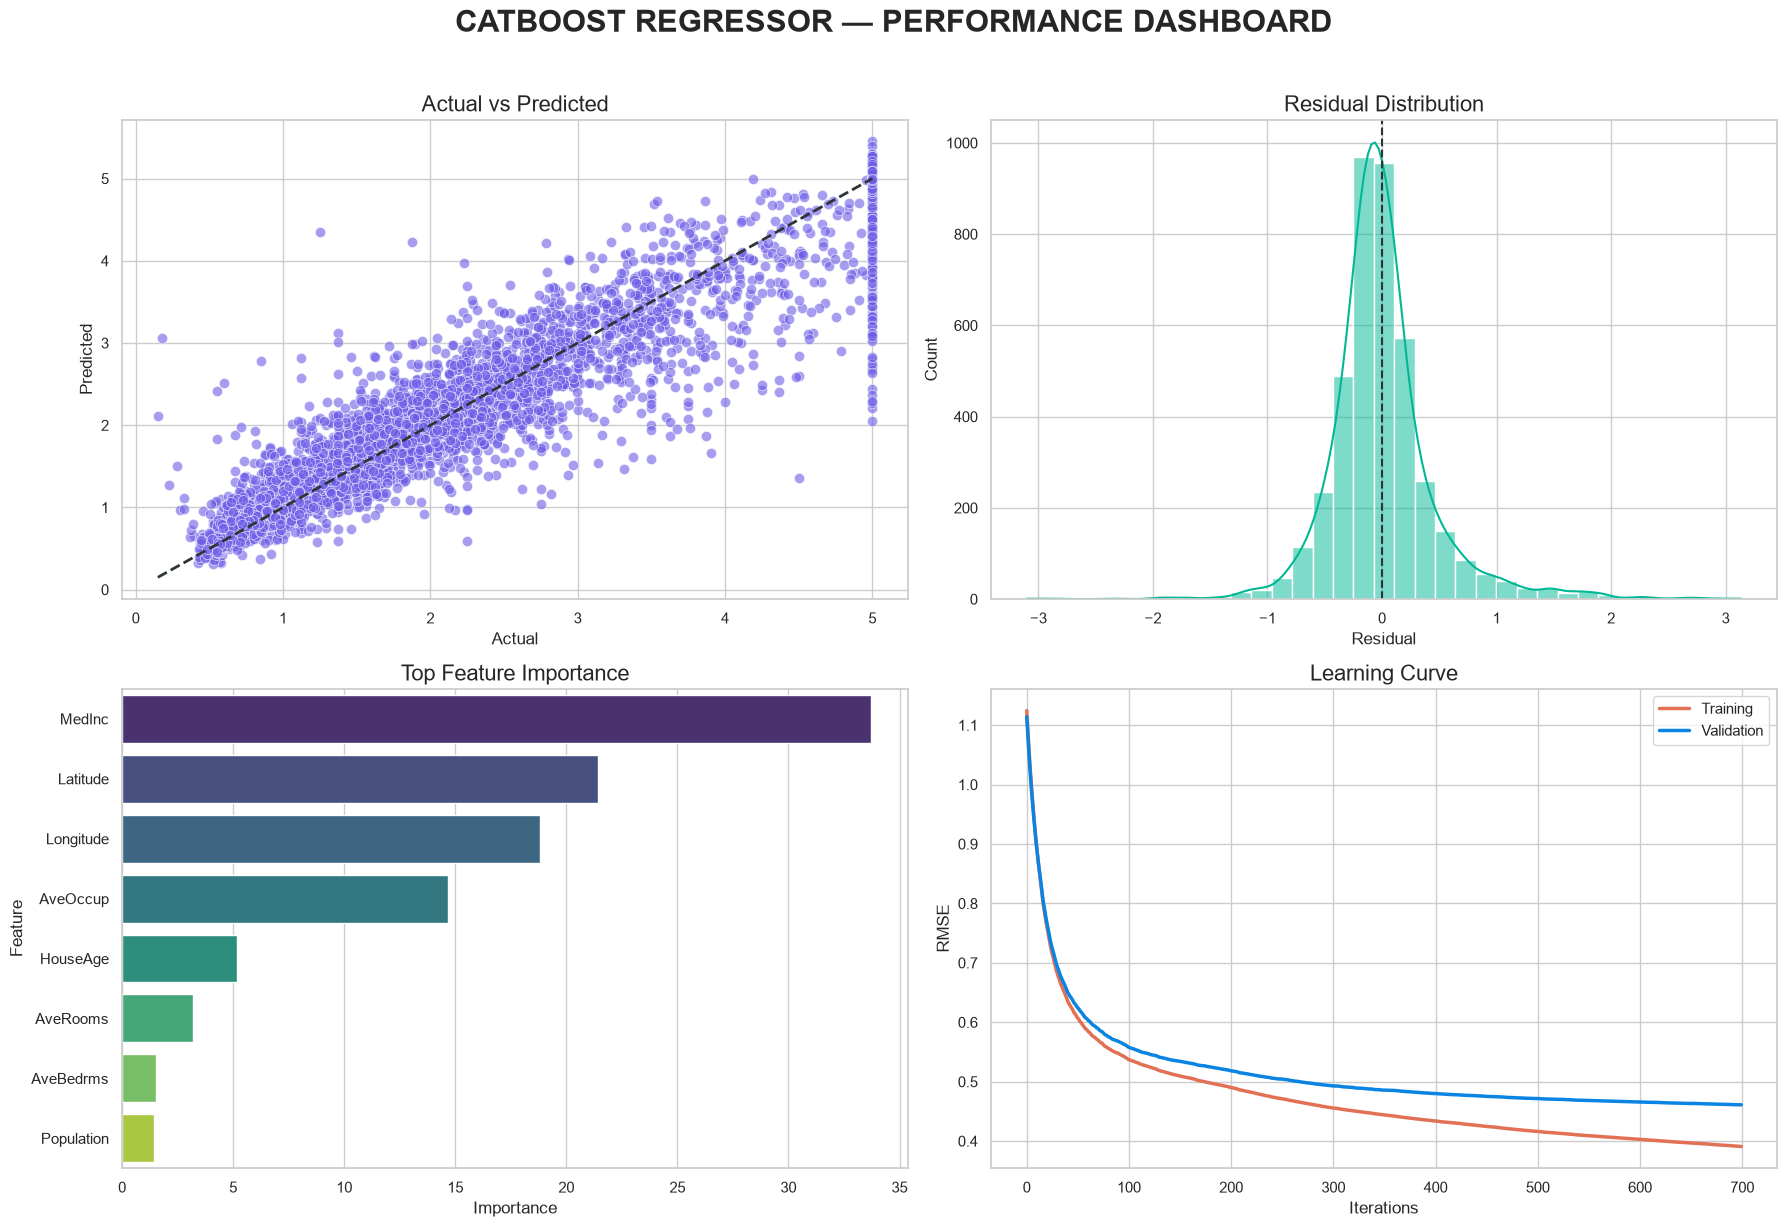

In [28]:
fig = plt.figure(figsize=(18, 12))

ax1 = plt.subplot(2, 2, 1)

sns.scatterplot(
    x=y_test,
    y=y_test_pred,
    color="#6C5CE7",
    alpha=0.6,
    s=55,
    ax=ax1
)

ax1.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "--",
    color="#2D3436",
    linewidth=2
)

ax1.set_title("Actual vs Predicted")
ax1.set_xlabel("Actual")
ax1.set_ylabel("Predicted")

ax2 = plt.subplot(2, 2, 2)

sns.histplot(
    residuals,
    bins=35,
    kde=True,
    color="#00B894",
    ax=ax2
)

ax2.axvline(
    0,
    linestyle="--",
    color="#2D3436"
)

ax2.set_title("Residual Distribution")
ax2.set_xlabel("Residual")

ax3 = plt.subplot(2, 2, 3)

top_features_plot = feature_importance.head(8)

sns.barplot(
    data=top_features_plot,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False,
    ax=ax3
)

ax3.set_title("Top Feature Importance")
ax3.set_xlabel("Importance")

ax4 = plt.subplot(2, 2, 4)

ax4.plot(
    train_rmse_history,
    label="Training",
    linewidth=2.5,
    color="#E17055"
)

ax4.plot(
    validation_rmse_history,
    label="Validation",
    linewidth=2.5,
    color="#0984E3"
)

ax4.set_title("Learning Curve")
ax4.set_xlabel("Iterations")
ax4.set_ylabel("RMSE")
ax4.legend()

plt.suptitle(
    "CATBOOST REGRESSOR — PERFORMANCE DASHBOARD",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()